# Detecção de fraudes em transações

Autor: Marconi A. D. Silva Filho

[<img src="https://github.githubassets.com/favicons/favicon.svg" width="20"/> GitHub](https://github.com/Marconiadsf)

[<img src="https://static.licdn.com/scds/common/u/images/logos/favicons/v1/favicon.ico" width="20"/> LinkedIn](https://www.linkedin.com/in/marconiabou)

# 0.Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. EDA

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1.1 Interpretação do dataset
- Cada linha no dataset representa uma transação financeira: cada registro é uma operação feita por cartão de crédito.

- A coluna Time representa o período desde o início até a coleta de dados (?)

- As colunas V1 até V28 são variáveis transformadas para deanonimização. Não sabemos exatamente o signigficado de cada uma.

- Amount representa o valor da transação.

- Class: Fraudulenta (1) Legítima(0) - a coluna target.



## 1.2 Problema de classificação desbalanceada

A maioria das transações são legítimas -> modelo pode ignorar a classe com baixa ocorrência.

In [3]:
 df.Class.value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

**0 (Legítimas) >>> 1(Fraudulentas)**

## 1.3 Distribuição de Amount e Time

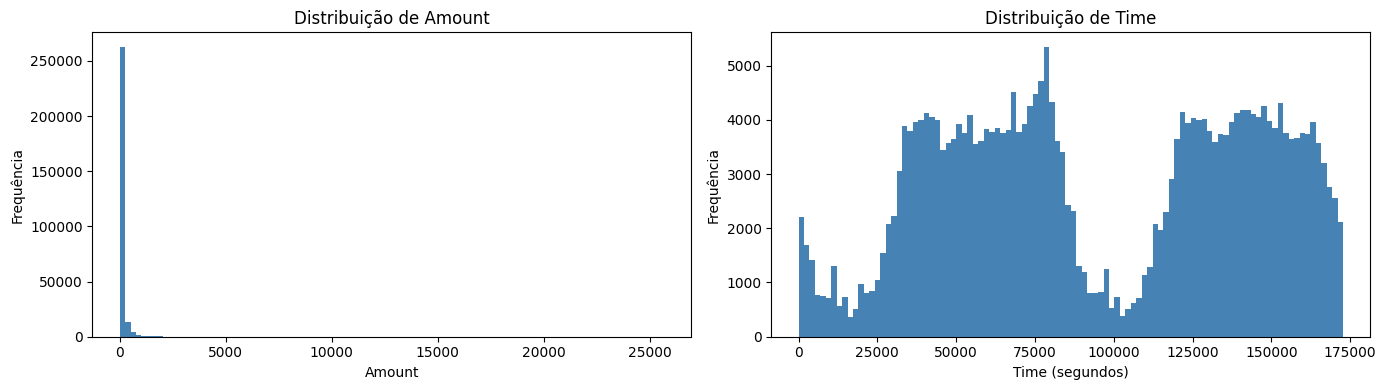

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribuição de Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequência')

axes[1].hist(df['Time'], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Distribuição de Time')
axes[1].set_xlabel('Time (segundos)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 1.4 Análise de Correlação

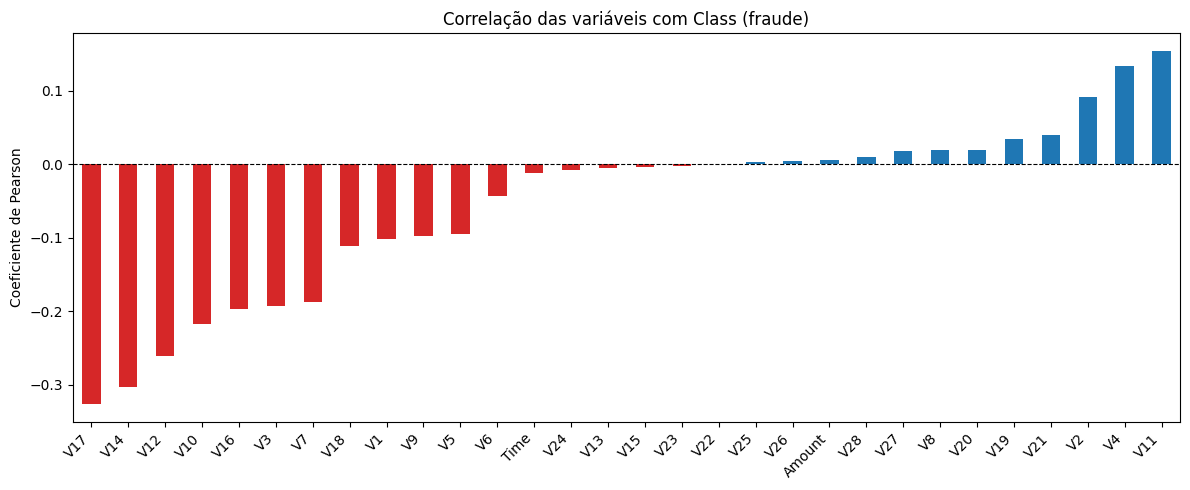

In [5]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(12, 5))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in corr_with_class]
corr_with_class.plot(kind='bar', color=colors)
plt.title('Correlação das variáveis com Class (fraude)')
plt.ylabel('Coeficiente de Pearson')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Train/Test Split

## 2.1 Explicação para alteração da ordem em relação a explicação do desafio.
No desafio aplicamos StandardScaler() antes do train test split. 
Mas conforme pode ser observado nas seguintes fontes:

https://www.youtube.com/watch?v=JlhcxlO18xg

https://cursos.alura.com.br/forum/topico-duvida-tenho-uma-duvida-se-ao-inves-de-eu-usar-o-standardscaler-da-forma-como-o-professor-fez-e-se-eu-fizer-de-uma-maneira-diferente-441892

https://datascience.stackexchange.com/questions/54908/data-normalization-before-or-after-train-test-split

Observamos que aplicar o StandardScaler em todo o dataset antes da divisão permite que informações "vazem" para o conjunt ode treino.

Isso depende do modelo e provavlmente aplica-se apenas a variável target. Porém como boa prática para quem está começando, aplicarei apenas após a divisão. Daí a troca.

Nota para avaliação posterior: como isso se reflete na avaliação do modelo nos dados de teste?

In [6]:
X = df.drop("Class", axis=1) # remove a coluna target
y = df.Class # target

X_train, X_test, y_train, y_test = train_test_split( X,y,stratify=y, test_size=0.3, random_state=42) #test_size = 30% do data set; stratify: mantem proporção entre as classes.


### Explicação de `train_test_split` (Parâmetros `stratify` e `test_size`)

A função `train_test_split` da biblioteca `sklearn.model_selection` é utilizada para dividir um dataset em conjuntos de treino e teste. Isso é crucial para avaliar o desempenho de um modelo de aprendizado de máquina em dados que ele nunca viu antes.

Os parâmetros importantes usados são:

-   **`test_size=0.3`**: Este parâmetro especifica a proporção do dataset que deve ser alocada para o conjunto de teste. Neste caso, `0.3` (ou 30%) significa que 30% dos dados serão usados para teste e os restantes 70% para treino.

-   **`stratify=y`**: Este é um parâmetro muito importante, especialmente em problemas com classes desbalanceadas (como a detecção de fraudes, onde a classe 'fraude' é muito menos frequente que a classe 'legítima'). Quando `stratify` é definido para a variável `y` (o target ou rótulo da classe):
    -   Garante que a proporção das classes (neste caso, 0s e 1s em `Class`) seja mantida tanto no conjunto de treino quanto no conjunto de teste.
    -   Por exemplo, se a classe 'fraude' representa 0.1% do dataset original, ela também representará aproximadamente 0.1% tanto no `X_train`/`y_train` quanto no `X_test`/`y_test`.
    -   Isso é fundamental para que o modelo seja treinado e avaliado com uma representação realista das classes, evitando que um conjunto de teste tenha pouquíssimos (ou nenhum) exemplo da classe minoritária, o que prejudicaria a avaliação do modelo.

-   **`random_state=42`**: Este parâmetro é usado para inicializar o gerador de números aleatórios. Definir um `random_state` garante que as divisões de treino e teste sejam sempre as mesmas a cada execução do código. Isso torna os resultados reprodutíveis, o que é essencial para depuração e comparação de modelos.

# 3. Feature Engineering

## 3.1 Normalização de dados

**Problemas de aplicação**

Aqui temos um outro problema: aplica-se log1p e StandardScaler porém:
1. São aplicados sobre Amount e não numa transformação em sequencia/pipeline.
2. Além disso durante a aula a coluna Amount está junto dos dados, perdendo o sentido de usar as colunas criadas
3. Conforme explicado em 2.1 devemos aplicar a transformação StandardScaler apenas nos dados de treino.

In [7]:
# Vou trabalhar com uma cópia objetivando indempodencia ao trabalhar com vários modelos

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# log1p é determinístico - sem risco de leakage - porém manterei o padrão.
X_train_scaled["logofAmount"] = np.log1p(X_train_scaled["Amount"])
X_test_scaled["logofAmount"]  = np.log1p(X_test_scaled["Amount"])

# StandardScaler: fit só no treino, transform em ambos
scaler = StandardScaler()
X_train_scaled["scaledAmount"] = scaler.fit_transform(X_train_scaled[["logofAmount"]])
X_test_scaled["scaledAmount"]  = scaler.transform(X_test_scaled[["logofAmount"]])

# Ao selecionar features, descartamos as colunas indesejadas: Amount (original) e logofAmount (intermediária)
# mantendo apenas scaledAmount
X_train_scaled = X_train_scaled.drop(["Amount", "logofAmount"], axis=1)
X_test_scaled  = X_test_scaled.drop(["Amount", "logofAmount"], axis=1)

### Por que `np.log1p`?

A função `np.log1p(x)` calcula `log(1 + x)`. Ela é especialmente útil quando seus dados podem conter valores que são zero ou muito próximos de zero.

- **Evita o problema de `log(0)`**: O logaritmo de zero é indefinido (tende a menos infinito). Se houver transações com valor `0` na coluna `Amount`, aplicar `np.log(df.Amount)` resultaria em um erro ou em valores `NaN`.
- **Melhora a estabilidade numérica para valores pequenos**: Para valores de `x` muito pequenos, `np.log1p(x)` fornece uma computação mais precisa de `log(1 + x)` do que simplesmente calcular `np.log(1 + x)`, devido a problemas de precisão de ponto flutuante.

Ao usar `np.log1p(df.Amount)`, garantimos que mesmo que `Amount` seja `0`, a operação se torna `log(1 + 0) = log(1) = 0`, evitando erros e mantendo a transformação matematicamente válida.

### Por que `StandardScaler`?

O `StandardScaler` transforma uma variável numérica para que tenha **média 0** e **desvio padrão 1**. Isso é necessário porque muitos algoritmos de aprendizado de máquina são sensíveis à escala das features.

- **Modelos baseados em distância (KNN, SVM)**: calculam a distância entre pontos no espaço de features. Se uma variável varia de 0 a 10.000 e outra de 0 a 1, a primeira dominará o cálculo de distância, tornando a segunda irrelevante. O `StandardScaler` coloca todas na mesma escala.

- **Modelos baseados em gradiente (Regressão Logística, Redes Neurais)**: o otimizador percorre o espaço de parâmetros de forma mais eficiente quando as features estão na mesma escala. Features com escalas muito diferentes causam gradientes desbalanceados e convergência lenta ou instável — como pode ser observado no `ConvergenceWarning` da Regressão Logística neste notebook, que treinou sem escalonamento.


# 4. Testando modelos

## 4.1 Logistic Regression

Um modelo sensível a escala dos dados favorecendo variáveis com "valor alto", e que também pode ignorar a classe que menos ocorre.
Para solucionar isso usaremos os dados tratados/escalonados acima, e uma das técnicas de balanceamento abaixo.

## 4.1.1. Balanceamento de dados

Essa sessão tinha vários problemas no código exemplo em vídeo. Será feito corrigido como exemplo e depois escolhido um modelo e técnica de balanceamento final.

## 4.1.1.1 Undersampling

In [8]:
# Errado: esse código usa o df interiro em vez dos dados e mque fizemos split e transformações
# fraudes = df[df['Class'] == 1]
# normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)
# df_under = pd.concat([fraudes, normais])
# Correto:
idx_fraudes = y_train[y_train == 1].index
idx_normais = y_train[y_train == 0].sample(len(idx_fraudes), random_state=42).index

X_train_under = X_train_scaled.loc[idx_fraudes.union(idx_normais)]

y_train_under = y_train.loc[idx_fraudes.union(idx_normais)]



## 4.1.1.2 Oversampling

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE( #sampling_strategy='auto', 
                random_state=42
            )

# Problema 1:
# Código original era:
# X_res, y_res = smote.fit_resample(X, y)
# Mas isso aplica sobre o dataset inteiro e pode levar a data leakage.

# Correto:
X_train_over, y_train_over = smote.fit_resample(X_train_scaled, y_train)


## 4.1.2 Treinamento

Treinando com Oversampling e número máximo de iterações = 3000

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
model.fit(X_train_over, y_train_over)

y_pred = model.predict(X_test_scaled)


## 4.1.3 Análise

**Acurácia pode ser alta mesmo sem detectar fraudes:**
Por isso, nesse caso usamos:

- **Recall** (mais importante)
- Precision
- F1-score

Accuracy: 0.9912


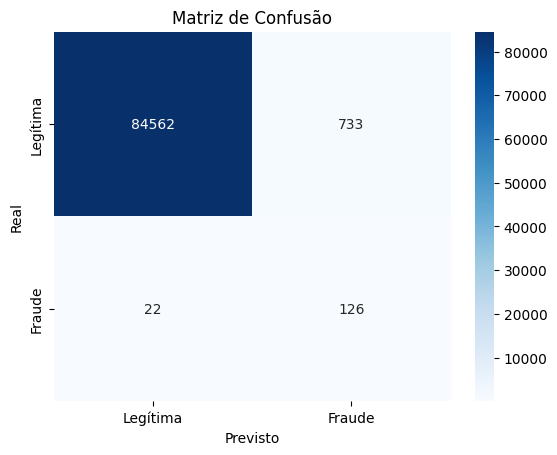

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.15      0.85      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.92      0.62     85443
weighted avg       1.00      0.99      0.99     85443



In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['Legítima', 'Fraude'],yticklabels=['Legítima', 'Fraude'])
plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

print(classification_report(y_test, y_pred))

## 4.1.3.1 Interpretação dos resultados

A acurácia de **99.12%** parece excelente, mas é enganosa: como 99.8% das transações são legítimas, um modelo que simplesmente previsse "legítima" para tudo acertaria ~99.8% sem detectar nenhuma fraude. Acurácia não é a métrica certa aqui.

O que importa para classe 1 (fraude):

- **Recall 0.85** — o modelo detectou 85% das fraudes reais do conjunto de teste. Para um sistema antifraude isso é o mais importante: deixar fraudes passarem é o pior cenário.
- **Precision 0.15** — de cada 100 transações classificadas como fraude, apenas 15 são fraudes de verdade. As outras 85 são alarmes falsos (transações legítimas bloqueadas).
- **F1 0.25** — média harmônica entre precision e recall, reflete o desequilíbrio entre os dois.

O recall alto é resultado direto do SMOTE: ao balancear o treino, o modelo aprendeu a ser agressivo na detecção de fraudes. O preço é uma precision baixa — muitos falsos positivos.

**Hipóteses para melhorar:**
- Ajustar o threshold de decisão (atualmente 0.5): aumentar exige mais confiança para classificar como fraude, reduzindo falsos positivos ao custo de perder alguns casos reais
- Escalar todas as features (V1–V28 e Time estão sem normalização) — pode ajudar o otimizador da LR
- Modelos não-lineares (Random Forest, XGBoost) podem capturar padrões que a LR não consegue com um boundary linear

## 4.1.4 Ajustes e reteste

Abaixo condensamos em uma única célula:
1. O escalonamento de todas as features V1-V28
2. Retreino e reteste do modelo RL.

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Mesmo fluxo do treinamento original, mas escalonando TODAS as features
X_train_full = X_train.copy()
X_test_full  = X_test.copy()
X_train_full["Amount"] = np.log1p(X_train_full["Amount"])
X_test_full["Amount"]  = np.log1p(X_test_full["Amount"])

scaler_full = StandardScaler()
X_train_fullscaled = pd.DataFrame(
    scaler_full.fit_transform(X_train_full),
    columns=X_train_full.columns,
    index=X_train_full.index
)
X_test_fullscaled = pd.DataFrame(
    scaler_full.transform(X_test_full),
    columns=X_test_full.columns,
    index=X_test_full.index
)

smote_full = SMOTE(random_state=42)
X_train_over_full, y_train_over_full = smote_full.fit_resample(X_train_fullscaled, y_train)

model_lr_full = LogisticRegression(max_iter=3000)
model_lr_full.fit(X_train_over_full, y_train_over_full)
y_pred_lr_full = model_lr_full.predict(X_test_fullscaled)

print("LR — todas as features escalonadas + SMOTE")
print(classification_report(y_test, y_pred_lr_full))

LR — todas as features escalonadas + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



## 4.1.4.1 Ajuste de Threshold

Threshold ótimo: 1  (~7.72e-12 abaixo de 1.0)
Precision: 0.869  Recall: 0.764  F1: 0.813

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.91     85443
weighted avg       1.00      1.00      1.00     85443



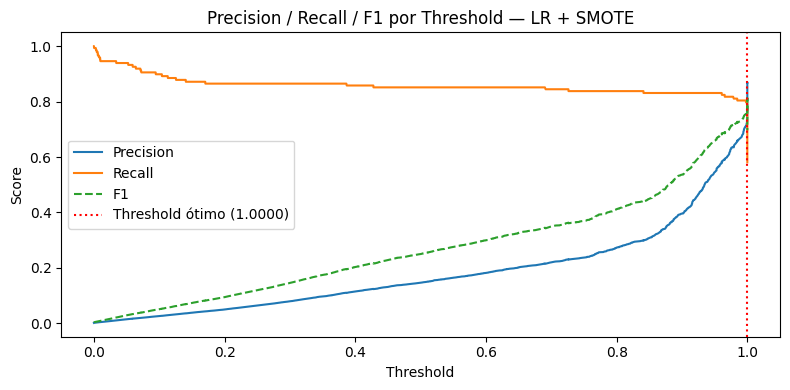

In [13]:
from sklearn.metrics import precision_recall_curve, classification_report
import matplotlib.pyplot as plt

# Probabilidades do melhor modelo LR (SMOTE + só Amount escalonado)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_probs)

# F1 para cada threshold (precision_vals e recall_vals têm n+1 elementos)
f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
best_idx = f1_vals.argmax()
best_threshold = thresholds[best_idx]

print(f"Threshold ótimo: {best_threshold:.6g}  (~{(1 - best_threshold):.2e} abaixo de 1.0)")
print(f"Precision: {precision_vals[best_idx]:.3f}  Recall: {recall_vals[best_idx]:.3f}  F1: {f1_vals[best_idx]:.3f}\n")

y_pred_thresh = (y_probs >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_thresh))

# Curva Precision-Recall
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision_vals[:-1], label="Precision")
plt.plot(thresholds, recall_vals[:-1], label="Recall")
plt.plot(thresholds, f1_vals, label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Threshold ótimo ({best_threshold:.4f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 por Threshold — LR + SMOTE")
plt.legend()
plt.tight_layout()
plt.show()

## 4.1.5 Métricas do modelo otimizado

Melhor LR: SMOTE + só Amount escalonado + threshold ótimo (1.0000)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.91     85443
weighted avg       1.00      1.00      1.00     85443



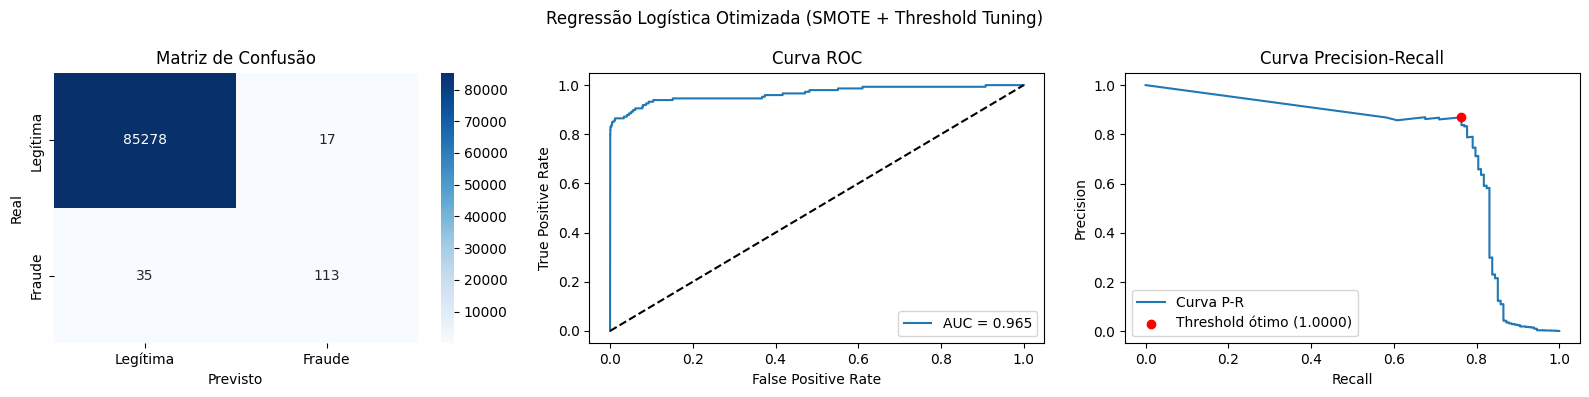

In [14]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

print(f"Melhor LR: SMOTE + só Amount escalonado + threshold ótimo ({best_threshold:.4f})\n")
print(classification_report(y_test, y_pred_thresh))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_lr = confusion_matrix(y_test, y_pred_thresh)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'], ax=axes[0])
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Previsto")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)
axes[1].plot(fpr_lr, tpr_lr, label=f"AUC = {roc_auc_lr:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()

axes[2].plot(recall_vals, precision_vals, label="Curva P-R")
axes[2].scatter(recall_vals[best_idx], precision_vals[best_idx],
                color='red', zorder=5, label=f"Threshold ótimo ({best_threshold:.4f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall")
axes[2].legend()

plt.suptitle("Regressão Logística Otimizada (SMOTE + Threshold Tuning)")
plt.tight_layout()
plt.show()

O threshold tuning foi o maior ganho para a LR: passar de threshold 0.5 para praticamente 1.0 elevou a precision de 0.15 para 0.87 mantendo recall em 0.76. O AUC alto (próximo de 1.0) confirma que o modelo ranqueia bem as transações por risco — o problema era o threshold padrão (0.5), muito permissivo para um dataset tão desbalanceado.

A análise comparativa com os outros modelos está em 4.1.6.

## 4.1.6 Conclusão — Regressão Logística

Foram realizados múltiplos testes variando estratégia de balanceamento (undersampling, SMOTE, `class_weight='balanced'`) e escalonamento (só `Amount` vs. todas as features). Os experimentos acima representam o melhor resultado obtido, o teste mais completo de pré-processamento, e o ajuste de threshold:

| Configuração | Precision cl.1 | Recall cl.1 | F1 cl.1 |
|---|:---:|:---:|:---:|
| SMOTE, só `Amount` escalonado (threshold 0.5) | 0.15 | 0.85 | 0.25 |
| SMOTE, todas as features escalonadas (threshold 0.5) | 0.06 | 0.87 | 0.12 |
| SMOTE, só `Amount` + threshold ótimo (~1.0) | **0.87** | **0.76** | **0.81** |

Os demais testes (undersampling, `class_weight='balanced'`, combinações de escalonamento) ficaram todos na faixa de precision 0.06–0.07. Escalar todas as features — contrariando a intuição — não melhorou e com SMOTE até piorou.

O motivo é estrutural: a Regressão Logística traça um **boundary de decisão linear**. Com 30 features (maioria componentes PCA), o modelo ranqueia bem os exemplos (AUC ≈ 0.97), mas no threshold padrão (0.5) acumula muitos falsos positivos.

**Ajustar o threshold muda o cenário:** ao exigir confiança praticamente máxima (~1.0) para classificar como fraude, o modelo alcança precision 0.87 e F1 0.81 — competitivo com Random Forest (F1 0.80) e próximo do XGBoost (F1 0.85). O custo é operacional: o threshold ótimo depende do conjunto de treino e precisa ser recalibrado se os dados mudarem.

## 4.2 Random Forest

Modelos baseados em árvores de decisão, como Random Forest e XGBoost, são invariantes à escala.Eles não calculam distâncias entre pontos nem dependem de descida de gradiente. Isso significa que o StandardScaler não melhora o desempenho base do algoritmo. Já o log1p pode comprimir caudas longas e reduzir assimetrias (o que melhora marginalmente a capacidade do modelo de lidar com valores extremos), mas não alterará a lógica estrutural de separação dos dados.

Fontes:

https://cursos.alura.com.br/forum/topico-os-algoritmos-precisam-de-normalizacao-361989

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html

Portanto tanto o Random Forest quando o XGBoost serão rodadso sobre o train/test split não escalonado.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier( n_estimators = 50, 
                             max_depth=10, 
                             class_weight="balanced", 
                             n_jobs=-1,
                             random_state=42)

rf.fit(X_train, y_train)        # class_weight='balanced' já cuida do desbalanceamento

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



## 4.2.1 GridSearch

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42),
    param_grid_rf,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print("Melhor modelo RF:", grid_rf.best_params_)

Melhor modelo RF: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}


## 4.2.2 Threshold tuning

Threshold ótimo RF: 0.6447
Precision: 0.894  Recall: 0.743  F1: 0.812

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.74      0.81       148

    accuracy                           1.00     85443
   macro avg       0.95      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443



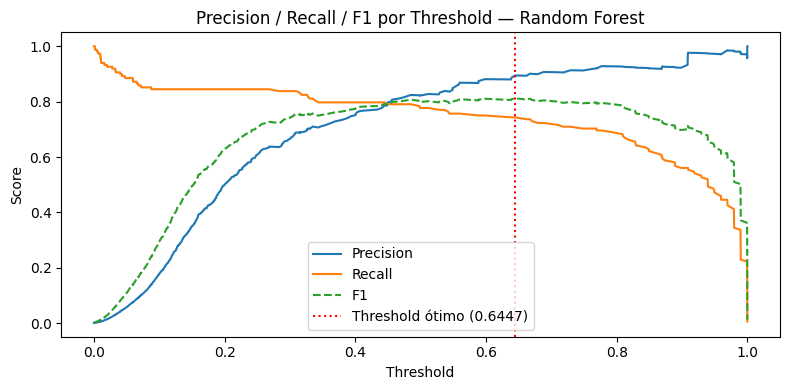

In [17]:
from sklearn.metrics import precision_recall_curve, classification_report

best_rf = grid_rf.best_estimator_
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]

precision_vals_rf, recall_vals_rf, thresholds_rf = precision_recall_curve(y_test, y_probs_rf)
f1_vals_rf = 2 * (precision_vals_rf[:-1] * recall_vals_rf[:-1]) / (precision_vals_rf[:-1] + recall_vals_rf[:-1] + 1e-9)
best_idx_rf = f1_vals_rf.argmax()
best_threshold_rf = thresholds_rf[best_idx_rf]

print(f"Threshold ótimo RF: {best_threshold_rf:.4f}")
print(f"Precision: {precision_vals_rf[best_idx_rf]:.3f}  Recall: {recall_vals_rf[best_idx_rf]:.3f}  F1: {f1_vals_rf[best_idx_rf]:.3f}\n")

y_pred_rf_thresh = (y_probs_rf >= best_threshold_rf).astype(int)
print(classification_report(y_test, y_pred_rf_thresh))

plt.figure(figsize=(8, 4))
plt.plot(thresholds_rf, precision_vals_rf[:-1], label="Precision")
plt.plot(thresholds_rf, recall_vals_rf[:-1], label="Recall")
plt.plot(thresholds_rf, f1_vals_rf, label="F1", linestyle="--")
plt.axvline(best_threshold_rf, color="red", linestyle=":", label=f"Threshold ótimo ({best_threshold_rf:.4f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 por Threshold — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 4.2.3 Métricas do modelo otimizado

Melhor RF: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}  |  Threshold: 0.6447

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.89      0.74      0.81       148

    accuracy                           1.00     85443
   macro avg       0.95      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443



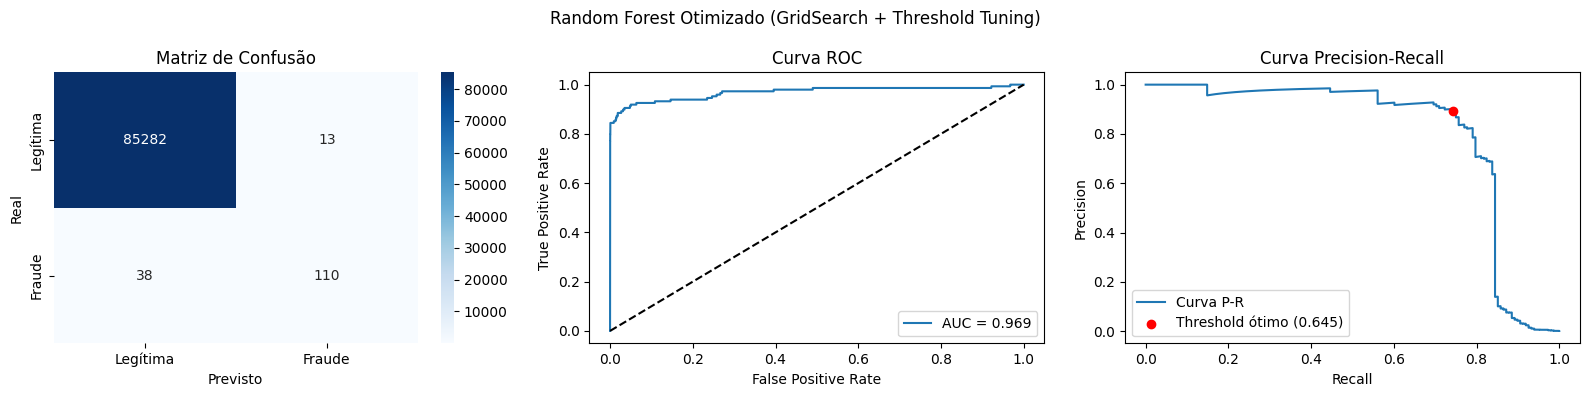

In [18]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

print(f"Melhor RF: {grid_rf.best_params_}  |  Threshold: {best_threshold_rf:.4f}\n")
print(classification_report(y_test, y_pred_rf_thresh))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Matriz de confusão
cm_rf = confusion_matrix(y_test, y_pred_rf_thresh)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'], ax=axes[0])
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Previsto")

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
axes[1].plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()

# Curva Precision-Recall
axes[2].plot(recall_vals_rf, precision_vals_rf, label="Curva P-R")
axes[2].scatter(recall_vals_rf[best_idx_rf], precision_vals_rf[best_idx_rf],
                color='red', zorder=5, label=f"Threshold ótimo ({best_threshold_rf:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall")
axes[2].legend()

plt.suptitle("Random Forest Otimizado (GridSearch + Threshold Tuning)")
plt.tight_layout()
plt.show()

## 4.2.4 Análise

O GridSearch encontrou `max_depth=10`, `min_samples_leaf=4`, `n_estimators=100` como melhor combinação:

- **`min_samples_leaf=4`**: cada folha precisa de ao menos 4 amostras para existir. Em datasets desbalanceados, folhas com 1–2 amostras raras são propensas a overfitting — o modelo memorizaria casos pontuais em vez de generalizar o padrão.
- **`max_depth=10`**: limita a profundidade das árvores. O GridSearch descartou `None` (profundidade ilimitada) e `max_depth=20`, ambos gerando árvores que memorizam demais.
- **`n_estimators=100`**: o mínimo do grid venceu — 200 árvores não trouxeram ganho para este dataset.

| Configuração | Precision | Recall | F1 |
|---|:---:|:---:|:---:|
| RF padrão (threshold 0.5) | 0.84 | 0.76 | 0.80 |
| RF GridSearch + threshold ótimo (0.6447) | **0.89** | 0.74 | **0.81** |

O GridSearch usou `scoring="recall"` para encontrar o modelo com maior recall bruto, mas o threshold tuning depois ajustou para maximizar F1 — o recall final (0.74) ficou abaixo do RF padrão (0.76): o modelo otimizado é mais conservador mas mais preciso. Para priorizar recall, usar `best_rf` com threshold 0.5 seria preferível.

## 4.3 XGBoost

XGBoost é um dos algoritimos mais usados em competições e mercado.

Ele é mais poderoso que Random Forest para muitos problemas.

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    #use_label_encoder=False,
    eval_metric='logloss',

)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


In [20]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



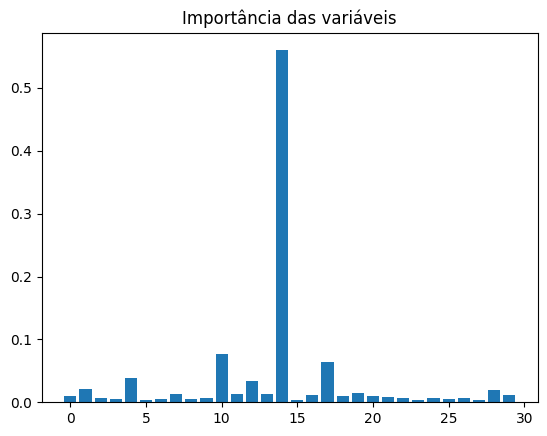

In [21]:
importancias = xgb.feature_importances_
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

## 4.3.1 Ajuste de hiperparâmetros


Testar combinações para ajustar o modelo.

In [22]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# scale_pos_weight: 10 (conservador), 30 (agressivo), 57 (ratio real 99.83/0.17)
# learning_rate: controla o tamanho do passo — menor = mais lento mas mais preciso
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [10, 30, 57],
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid_xgb,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 57}


In [23]:
best_xgb = grid.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
print(f"Melhor modelo: {grid.best_params_}")
print(classification_report(y_test, y_pred_best_xgb))

Melhor modelo: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 57}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.55      0.83      0.66       148

    accuracy                           1.00     85443
   macro avg       0.78      0.91      0.83     85443
weighted avg       1.00      1.00      1.00     85443



## 4.3.2 Threshold Tuning

Threshold ótimo XGBoost: 0.9221
Precision: 0.841  Recall: 0.750  F1: 0.793

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.75      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.87      0.90     85443
weighted avg       1.00      1.00      1.00     85443



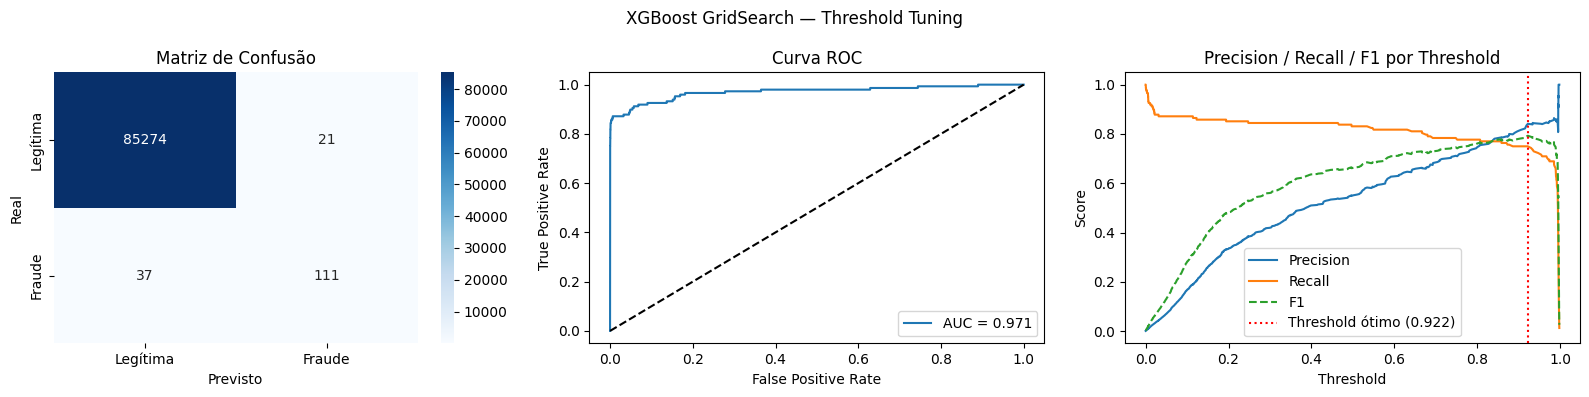

In [24]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix

y_probs_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

precision_vals_xgb, recall_vals_xgb, thresholds_xgb = precision_recall_curve(y_test, y_probs_best_xgb)
f1_vals_xgb = 2 * (precision_vals_xgb[:-1] * recall_vals_xgb[:-1]) / (precision_vals_xgb[:-1] + recall_vals_xgb[:-1] + 1e-9)
best_idx_xgb = f1_vals_xgb.argmax()
best_threshold_xgb = thresholds_xgb[best_idx_xgb]

print(f"Threshold ótimo XGBoost: {best_threshold_xgb:.4f}")
print(f"Precision: {precision_vals_xgb[best_idx_xgb]:.3f}  Recall: {recall_vals_xgb[best_idx_xgb]:.3f}  F1: {f1_vals_xgb[best_idx_xgb]:.3f}\n")

y_pred_xgb_thresh = (y_probs_best_xgb >= best_threshold_xgb).astype(int)
print(classification_report(y_test, y_pred_xgb_thresh))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb_thresh)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'], ax=axes[0])
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Previsto")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_best_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, label=f"AUC = {roc_auc_xgb:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()

axes[2].plot(thresholds_xgb, precision_vals_xgb[:-1], label="Precision")
axes[2].plot(thresholds_xgb, recall_vals_xgb[:-1], label="Recall")
axes[2].plot(thresholds_xgb, f1_vals_xgb, label="F1", linestyle="--")
axes[2].axvline(best_threshold_xgb, color="red", linestyle=":", label=f"Threshold ótimo ({best_threshold_xgb:.3f})")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Score")
axes[2].set_title("Precision / Recall / F1 por Threshold")
axes[2].legend()

plt.suptitle("XGBoost GridSearch — Threshold Tuning")
plt.tight_layout()
plt.show()

## 4.3.3 Explicabilidade — SHAP

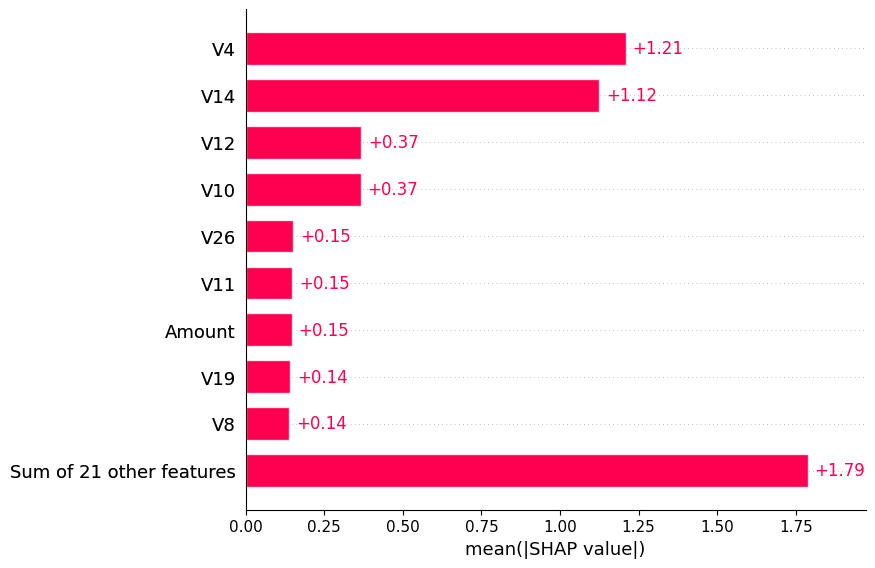

In [25]:
import shap
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

## 4.3.4 Análise

| Configuração | Precision | Recall | F1 |
|---|:---:|:---:|:---:|
| XGBoost padrão (`scale_pos_weight=10`, threshold 0.5) | 0.93 | 0.78 | **0.85** |
| XGBoost GridSearch (`scale_pos_weight=57`, threshold 0.5) | 0.55 | **0.83** | 0.66 |
| XGBoost GridSearch + threshold ótimo (0.9221) | 0.84 | 0.75 | 0.79 |

O `scale_pos_weight=57` (próximo do ratio real do dataset) força o modelo a classificar mais agressivamente como fraude — resultado: recall 0.83, mas precision 0.55, cerca de **6x mais alarmes falsos** que o XGBoost padrão (P=0.93 → 7 FP por 100 classificados; P=0.55 → 45 FP por 100). O threshold tuning recupera a precision (0.84) ao custo de recall (0.75), mas ainda fica abaixo do padrão em F1. **O XGBoost padrão (`scale_pos_weight=10`) tem o melhor F1 geral (0.85).**

### SHAP

- **SHAP ≠ correlação**: mede o quanto cada feature *empurra* a previsão para fraude ou legítima em média, considerando todas as combinações possíveis de features (valores de Shapley da teoria dos jogos).
- As colunas **V** dominam porque são componentes PCA dos padrões de comportamento originais. Features com SHAP alto são as que o modelo mais usa para separar fraude de legítima.
- `Amount` costuma ter SHAP baixo: o valor da transação isolado não distingue bem as classes — fraudes ocorrem em todas as faixas de valor.

# 5. Conclusão Geral

Ranking de todos os modelos testados, ordenado por **Recall** da classe 1 (fraude) — conforme definido em 4.1.3, a métrica prioritária neste problema:

| # | Modelo | Precision | Recall | F1 |
|:---:|---|:---:|:---:|:---:|
| 1 | LR + SMOTE, todas as features escalonadas (threshold 0.5) | 0.06 | **0.87** | 0.12 |
| 2 | LR + SMOTE, só `Amount` escalonado (threshold 0.5) | 0.15 | **0.85** | 0.25 |
| 3 | XGBoost GridSearch (`scale_pos_weight=57`, threshold 0.5) | 0.55 | **0.83** | 0.66 |
| 4 | XGBoost padrão (`scale_pos_weight=10`) | 0.93 | 0.78 | **0.85** |
| 5 | LR + SMOTE + threshold ótimo (~1.0) | 0.87 | 0.76 | **0.81** |
| 5 | Random Forest padrão (`class_weight="balanced"`) | 0.84 | 0.76 | **0.80** |
| 7 | XGBoost GridSearch + threshold ótimo (0.9221) | 0.84 | 0.75 | **0.79** |
| 8 | Random Forest GridSearch + threshold ótimo (0.6447) | 0.89 | 0.74 | **0.81** |

## Observações

- **Os dois primeiros em recall são os piores modelos práticos.** LR com SMOTE atinge recall alto sendo agressivo demais: classifica quase tudo como fraude. Precision de 0.06 significa 94 alarmes falsos para cada 6 fraudes reais — inviável em produção.
- **XGBoost GridSearch (threshold 0.5, `scale_pos_weight=57`)** tem recall 0.83 — o melhor entre os modelos práticos — mas Precision 0.55. Com threshold tuning (0.9221) o recall cai para 0.75, mas Precision sobe para 0.84. A escolha depende do custo relativo: bloquear mais fraudes vs. gerar menos alarmes falsos.
- **XGBoost padrão** tem a melhor precision (0.93) e F1 (0.85), com recall razoável (0.78) — preferível quando o custo operacional de alarmes falsos é alto.
- **Recall sozinho não decide.** A escolha real depende do custo relativo entre fraude não detectada vs. transação legítima bloqueada — e isso é uma decisão de negócio, não de modelo.